In [88]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

import sys
import os
sys.path.append(os.path.abspath('..'))
from src.db_connection import get_engine

In [51]:
engine=get_engine()

In [52]:
## Fraud percentage
df=pd.read_sql('select * from transactions', engine)

In [53]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [54]:
## Fraud Percentage
x=df['Class'].value_counts(normalize=True)*100


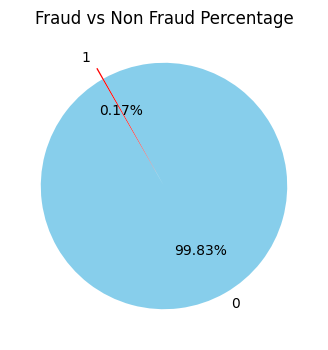

In [55]:
plt.figure(figsize=(4,4))
plt.pie(x, labels=x.index, autopct='%1.2f%%',startangle=120, colors=['skyblue', 'red'], explode=(0,0.1))
plt.title('Fraud vs Non Fraud Percentage')

plt.savefig('../reports/figures/fraud_percentage.png',  dpi=300, bbox_inches='tight')
plt.show()

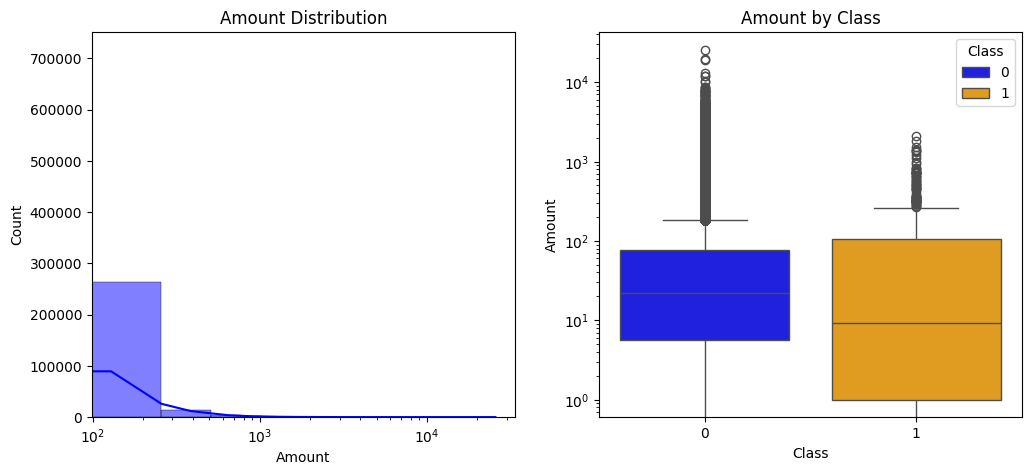

In [92]:
#Amount distribution (log scale as data is highly skewed)
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.histplot(df['Amount'],bins=100,kde=True, color='blue')
plt.title('Amount Distribution')
plt.xscale('log')

plt.subplot(1,2,2)
# sns.boxplot(data=df, x='Class',y='Amount', hue='Class', palette=['#1f77b4','#ff7f0e'])
sns.boxplot(data=df, x='Class',y='Amount', hue='Class', palette=['blue','orange'])

plt.title('Amount by Class')
plt.yscale('log')
plt.savefig('../reports/figures/amount_distribution.png',  dpi=300, bbox_inches='tight')
plt.show()



In [74]:
df['hour']=df['Time']/3600%24

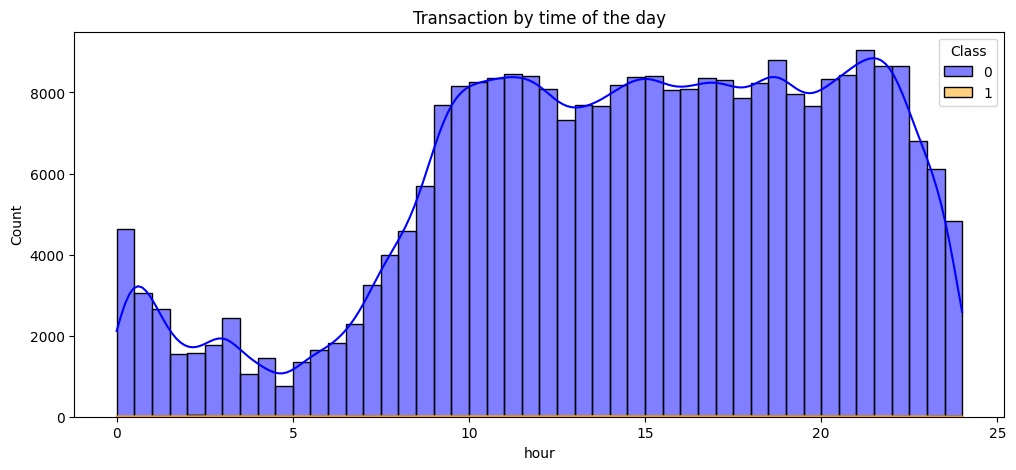

In [93]:
plt.figure(figsize=(12,5))
sns.histplot(data=df,x='hour',bins=48,kde=True,multiple='stack',palette=['blue','orange'],hue='Class')
plt.title('Transaction by time of the day')
plt.savefig('../reports/figures/transaction_by_time.png',  dpi=300, bbox_inches='tight')
plt.show()

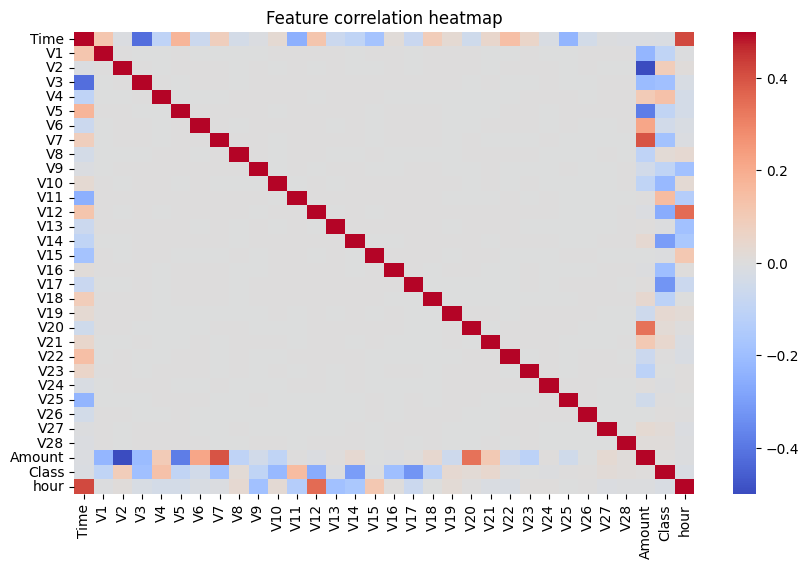

In [94]:
## correlation heatmap

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(),cmap='coolwarm', annot=False, vmin=-0.5, vmax=0.5)
plt.title('Feature correlation heatmap')
plt.savefig('../reports/figures/feature_correlation.png',  dpi=300, bbox_inches='tight')
plt.show()

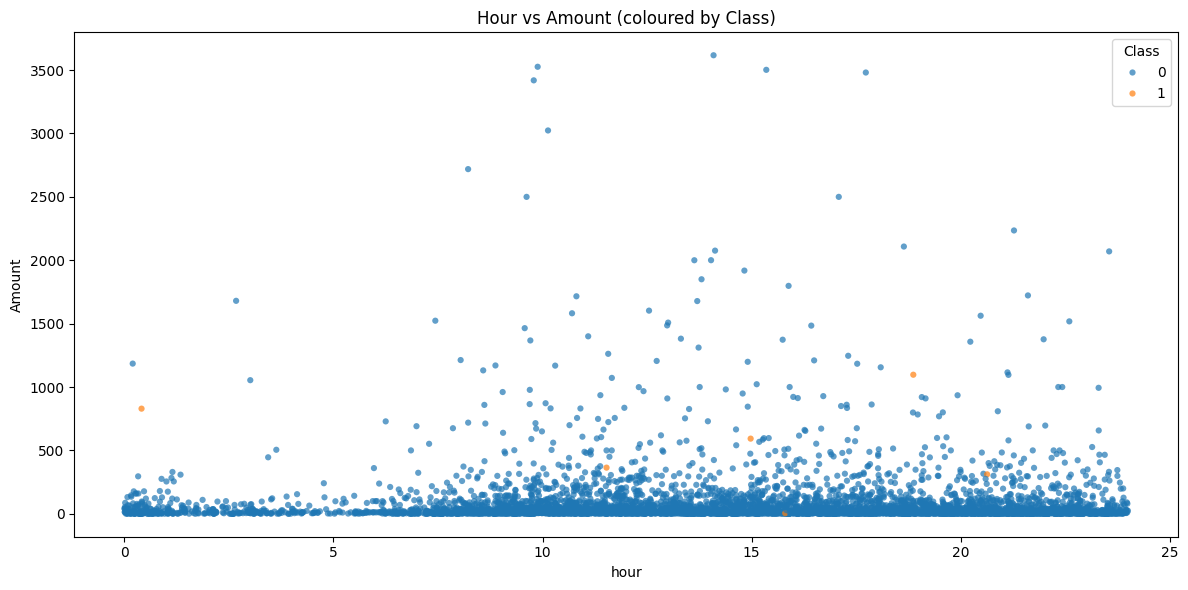

In [100]:
# scatter plot(Amount vs Hour)
sample_df=df.sample(5000,random_state=42)

plt.figure(figsize=(12,6))

sns.scatterplot(
    data=sample_df,
    x='hour',
    y='Amount',
    hue='Class',
    palette=['#1f77b4','#ff7f0e'],
    alpha=0.7,
    s=20,
    edgecolor='none'
)

plt.title('Hour vs Amount (coloured by Class)')
plt.tight_layout()
plt.savefig('../reports/figures/Hour_vs_Amount.png',  dpi=300, bbox_inches='tight')
plt.show()